# AquaVision: Part 2 - Advanced Modeling & Water Quality Prediction
## Feature Engineering, Model Development, and Performance Optimization

### Phase 2 Overview:
- Domain-specific feature engineering
- Water Quality Index (WQI) computation using multiple methods
- Advanced predictive modeling (Linear Regression, Random Forest, XGBoost, LightGBM)
- Hyperparameter optimization and ensemble methods
- Comprehensive model evaluation and interpretation
- Feature importance and SHAP analysis

## 1. Load Preprocessed Data and Libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance, partial_dependence
import xgboost as xgb
import lightgbm as lgb

from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [75]:
# Load preprocessed data
df_clean = pd.read_csv('../outputs/01_data_cleaned.csv')
df_features = pd.read_csv('../outputs/02_data_with_features.csv')
df_features['Date'] = pd.to_datetime(df_features['Date'])

print("Data loaded successfully!")
print(f"  Shape: {df_features.shape}")
print(f"  Features: {df_features.shape[1]}")

print("\nFirst few records:")
display(df_features.head())

Data loaded successfully!
  Shape: (730, 32)
  Features: 32

First few records:


,Date,Location,pH,Dissolved_Oxygen_mg_L,Turbidity_NTU,Conductivity_uS_cm,Temperature_C,Hardness_mg_L,Chloride_mg_L,Ammonia_mg_L,...,Month,Day,DayOfWeek,Quarter,Week,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Season
0,2022-01-01,Rural_West,7.482338,15.0,4.170814,616.250653,18.558003,241.061185,28.790228,1.525627,...,1,1,5,1,52,0.5,0.866025,-0.974928,-0.222521,Winter
1,2022-01-02,Industrial,8.455687,15.0,6.030984,539.517417,24.630370,226.215027,35.706811,0.430293,...,1,2,6,1,52,0.5,0.866025,-0.781831,0.623490,Winter
2,2022-01-03,Rural_East,7.162338,15.0,0.000000,588.990826,20.776868,218.961881,28.305594,1.327389,...,1,3,0,1,1,0.5,0.866025,0.000000,1.000000,Winter
3,2022-01-04,Industrial,5.502368,15.0,0.000000,285.217374,32.911535,228.672212,16.016990,0.781989,...,1,4,1,1,1,0.5,0.866025,0.781831,0.623490,Winter
4,2022-01-05,Industrial,7.492561,15.0,4.981082,464.746529,28.146333,170.306641,49.955744,1.185384,...,1,5,2,1,1,0.5,0.866025,0.974928,-0.222521,Winter


## 2. Advanced Feature Engineering

In [76]:
# Domain-specific feature engineering
print("="*80)
print("DOMAIN-SPECIFIC FEATURE ENGINEERING")
print("="*80)

df_eng = df_features.copy()

# 1. Chemical interaction features
df_eng['DO_pH_Interaction'] = df_eng['Dissolved_Oxygen_mg_L'] * (df_eng['pH'] - 7)**2  # pH deviation effect
df_eng['Hardness_Conductivity_Ratio'] = df_eng['Hardness_mg_L'] / (df_eng['Conductivity_uS_cm'] + 1)
df_eng['Pollutant_Index'] = (df_eng['Ammonia_mg_L'] + df_eng['Nitrate_mg_L'] + df_eng['Phosphate_mg_L']) / 3

# 2. Oxidation and reduction potential indicators
df_eng['Redox_Indicator'] = df_eng['Dissolved_Oxygen_mg_L'] - (df_eng['BOD_mg_L'] + df_eng['COD_mg_L']) / 10
df_eng['Ion_Balance'] = (df_eng['Chloride_mg_L'] + df_eng['Sulfate_mg_L']) / (df_eng['Hardness_mg_L'] + 1)

# 3. Microbial contamination index
df_eng['Microbial_Load'] = np.log1p(df_eng['Total_Coliform_CFU_100mL'] + df_eng['E_Coli_CFU_100mL'])
df_eng['E_Coli_Ratio'] = df_eng['E_Coli_CFU_100mL'] / (df_eng['Total_Coliform_CFU_100mL'] + 1)

# 4. Organic contamination index
df_eng['Organic_Load'] = (df_eng['BOD_mg_L'] + df_eng['COD_mg_L']) / 2
df_eng['BOD_COD_Ratio'] = df_eng['BOD_mg_L'] / (df_eng['COD_mg_L'] + 0.1)

# 5. Heavy metal contamination index
df_eng['Metal_Index'] = np.sqrt((df_eng['Iron_mg_L']**2 + df_eng['Manganese_mg_L']**2)) / 2

# 6. Nutrient enrichment index
df_eng['Nutrient_Index'] = df_eng['Nitrogen_mg_L'] if 'Nitrogen_mg_L' in df_eng.columns else (df_eng['Ammonia_mg_L'] + df_eng['Nitrate_mg_L']) / 2

# 7. Turbidity-related features
df_eng['Turbidity_Log'] = np.log1p(df_eng['Turbidity_NTU'])
df_eng['Suspended_Matter_Index'] = df_eng['Turbidity_NTU'] * df_eng['Temperature_C'] / 20  # Temperature effect

# 8. Rolling averages for temporal patterns
df_eng = df_eng.sort_values('Date').reset_index(drop=True)
key_params = ['pH', 'Dissolved_Oxygen_mg_L', 'Turbidity_NTU', 'WQI']
for param in key_params:
    if param in df_eng.columns:
        df_eng[f'{param}_rolling_7d'] = df_eng[param].rolling(window=7, min_periods=1).mean()
        df_eng[f'{param}_rolling_30d'] = df_eng[param].rolling(window=30, min_periods=1).mean()
        df_eng[f'{param}_rolling_std'] = df_eng[param].rolling(window=7, min_periods=1).std()

print("Domain-specific features engineered:")
print(f"  New features added: {len(df_eng.columns) - len(df_features.columns)}")
print(f"  Total features now: {len(df_eng.columns)}")

DOMAIN-SPECIFIC FEATURE ENGINEERING
Domain-specific features engineered:
  New features added: 25
  Total features now: 57


In [77]:
# Remove any columns with NaN from rolling operations
df_eng = df_eng.dropna()
print(f"Final clean records: {len(df_eng)}")

# Display new engineered features
engineered_cols = [col for col in df_eng.columns if col not in df_features.columns]
print(f"\nEngineered Features Summary:")
for i, col in enumerate(engineered_cols, 1):
    print(f"  {i}. {col}")

Final clean records: 729

Engineered Features Summary:
  1. DO_pH_Interaction
  2. Hardness_Conductivity_Ratio
  3. Pollutant_Index
  4. Redox_Indicator
  5. Ion_Balance
  6. Microbial_Load
  7. E_Coli_Ratio
  8. Organic_Load
  9. BOD_COD_Ratio
  10. Metal_Index
  11. Nutrient_Index
  12. Turbidity_Log
  13. Suspended_Matter_Index
  14. pH_rolling_7d
  15. pH_rolling_30d
  16. pH_rolling_std
  17. Dissolved_Oxygen_mg_L_rolling_7d
  18. Dissolved_Oxygen_mg_L_rolling_30d
  19. Dissolved_Oxygen_mg_L_rolling_std
  20. Turbidity_NTU_rolling_7d
  21. Turbidity_NTU_rolling_30d
  22. Turbidity_NTU_rolling_std
  23. WQI_rolling_7d
  24. WQI_rolling_30d
  25. WQI_rolling_std


## 3. Prepare Data for Modeling

In [78]:
# Select features for modeling
print("="*80)
print("PREPARING DATA FOR MODELING")
print("="*80)

# Exclude non-numeric and date columns
exclude_cols = ['Date', 'Location', 'Season', 'WQI', 'Potability']
feature_cols = [col for col in df_eng.columns if col not in exclude_cols and df_eng[col].dtype in ['float64', 'int64']]

# Prepare feature matrix and target variable
X = df_eng[feature_cols].copy()
y = df_eng['WQI'].copy()

# Handle categorical variable (Location)
X_with_cat = X.copy()
X_with_cat['Location'] = pd.factorize(df_eng['Location'])[0]
X_with_cat['Season'] = pd.factorize(df_eng['Season'])[0]

print(f"\nFeature matrix shape: {X_with_cat.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeature list ({len(feature_cols)} features):")
for i, col in enumerate(feature_cols, 1):
    if i % 5 == 0:
        print(f"  {i}. {col}")
    else:
        print(f"  {i}. {col}", end=" ")
        
if len(feature_cols) % 5 != 0:
    print()  # New line after odd number of features

print(f"\nTarget variable (WQI) statistics:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std: {y.std():.2f}")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")

PREPARING DATA FOR MODELING

Feature matrix shape: (729, 54)
Target variable shape: (729,)

Feature list (52 features):
  1. pH   2. Dissolved_Oxygen_mg_L   3. Turbidity_NTU   4. Conductivity_uS_cm   5. Temperature_C
  6. Hardness_mg_L   7. Chloride_mg_L   8. Ammonia_mg_L   9. Nitrate_mg_L   10. Phosphate_mg_L
  11. Iron_mg_L   12. Manganese_mg_L   13. Sulfate_mg_L   14. Total_Coliform_CFU_100mL   15. E_Coli_CFU_100mL
  16. BOD_mg_L   17. COD_mg_L   18. Year   19. Month   20. Day
  21. DayOfWeek   22. Quarter   23. Week   24. Month_sin   25. Month_cos
  26. DayOfWeek_sin   27. DayOfWeek_cos   28. DO_pH_Interaction   29. Hardness_Conductivity_Ratio   30. Pollutant_Index
  31. Redox_Indicator   32. Ion_Balance   33. Microbial_Load   34. E_Coli_Ratio   35. Organic_Load
  36. BOD_COD_Ratio   37. Metal_Index   38. Nutrient_Index   39. Turbidity_Log   40. Suspended_Matter_Index
  41. pH_rolling_7d   42. pH_rolling_30d   43. pH_rolling_std   44. Dissolved_Oxygen_mg_L_rolling_7d   45. Dissolve

In [79]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_with_cat, y, test_size=0.2, random_state=42)

print(f"\nTrain-Test Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Testing set: {X_test.shape[0]} samples")
print(f"  Train/Test ratio: {len(X_train)/len(X_test):.2f}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData standardized for modeling")


Train-Test Split:
  Training set: 583 samples
  Testing set: 146 samples
  Train/Test ratio: 3.99

Data standardized for modeling


## 4. Train Multiple ML Models

In [80]:
print("="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

models = {}
results = []

# 1. Linear Regression
print("\n1. Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results.append({
    'Model': 'Linear Regression',
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'R2': r2_lr,
    'MSE': mse_lr
})
models['Linear Regression'] = lr_model
print(f"  RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}")

MODEL TRAINING AND EVALUATION

1. Training Linear Regression...
  RMSE: 3.3465, R²: 0.5723


In [81]:
# 2. Random Forest
print("\n2. Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Random Forest doesn't require scaling
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results.append({
    'Model': 'Random Forest',
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    'R2': r2_rf,
    'MSE': mse_rf
})
models['Random Forest'] = rf_model
print(f"  RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")


2. Training Random Forest Regressor...
  RMSE: 3.8779, R²: 0.4257


In [82]:
# 3. XGBoost
print("\n3. Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

results.append({
    'Model': 'XGBoost',
    'RMSE': rmse_xgb,
    'MAE': mae_xgb,
    'R2': r2_xgb,
    'MSE': mse_xgb
})
models['XGBoost'] = xgb_model
print(f"  RMSE: {rmse_xgb:.4f}, R²: {r2_xgb:.4f}")


3. Training XGBoost Regressor...
  RMSE: 3.6477, R²: 0.4919


In [83]:
# 4. LightGBM
print("\n4. Training LightGBM Regressor...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='rmse')
y_pred_lgb = lgb_model.predict(X_test)

mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

results.append({
    'Model': 'LightGBM',
    'RMSE': rmse_lgb,
    'MAE': mae_lgb,
    'R2': r2_lgb,
    'MSE': mse_lgb
})
models['LightGBM'] = lgb_model
print(f"  RMSE: {rmse_lgb:.4f}, R²: {r2_lgb:.4f}")


4. Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7847
[LightGBM] [Info] Number of data points in the train set: 583, number of used features: 54
[LightGBM] [Info] Start training from score 85.911949
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

## 5. Model Performance Comparison

In [84]:
# Compare all models
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print("\n")
display(results_df)

print("\nBest Model: " + results_df.iloc[0]['Model'])
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"Best R²: {results_df.iloc[0]['R2']:.4f}")


MODEL PERFORMANCE COMPARISON




,Model,RMSE,MAE,R2,MSE
0,Linear Regression,3.346531,1.699375,0.572291,11.199269
2,XGBoost,3.647672,1.936794,0.491852,13.305512
3,LightGBM,3.682583,1.973127,0.482079,13.561419
1,Random Forest,3.877892,2.109906,0.425685,15.038044



Best Model: Linear Regression
Best RMSE: 3.3465
Best R²: 0.5723


In [85]:
# Visualization of model comparison
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('RMSE Comparison', 'MAE Comparison', 'R² Score Comparison')
)

fig.add_trace(
    go.Bar(x=results_df['Model'], y=results_df['RMSE'], name='RMSE', marker_color='lightblue'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=results_df['Model'], y=results_df['MAE'], name='MAE', marker_color='lightgreen'),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=results_df['Model'], y=results_df['R2'], name='R²', marker_color='lightyellow'),
    row=1, col=3
)

fig.update_xaxes(title_text="Model", row=1, col=1)
fig.update_xaxes(title_text="Model", row=1, col=2)
fig.update_xaxes(title_text="Model", row=1, col=3)
fig.update_yaxes(title_text="RMSE", row=1, col=1)
fig.update_yaxes(title_text="MAE", row=1, col=2)
fig.update_yaxes(title_text="R²", row=1, col=3)

fig.update_layout(height=400, showlegend=False, title_text="Model Performance Metrics Comparison")
fig.show()

print("Model comparison visualization generated")

Model comparison visualization generated


## 6. Feature Importance Analysis

In [86]:
# Feature importance from tree-based models
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Use the exact columns used to train XGBoost
model_feature_cols = X_train.columns.tolist()

# XGBoost feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': model_feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Important Features (XGBoost):")
print(feature_importance_xgb.head(15).to_string(index=False))

FEATURE IMPORTANCE ANALYSIS

Top 15 Important Features (XGBoost):
                          Feature  Importance
                    Turbidity_Log    0.252712
                    Turbidity_NTU    0.093669
         Total_Coliform_CFU_100mL    0.065759
                  WQI_rolling_std    0.061413
                     Ammonia_mg_L    0.058713
                DO_pH_Interaction    0.053448
                   Microbial_Load    0.038505
                   WQI_rolling_7d    0.037296
Dissolved_Oxygen_mg_L_rolling_std    0.025435
 Dissolved_Oxygen_mg_L_rolling_7d    0.021403
                            Month    0.019210
           Suspended_Matter_Index    0.018554
                   pH_rolling_std    0.017783
                     E_Coli_Ratio    0.017039
Dissolved_Oxygen_mg_L_rolling_30d    0.016360


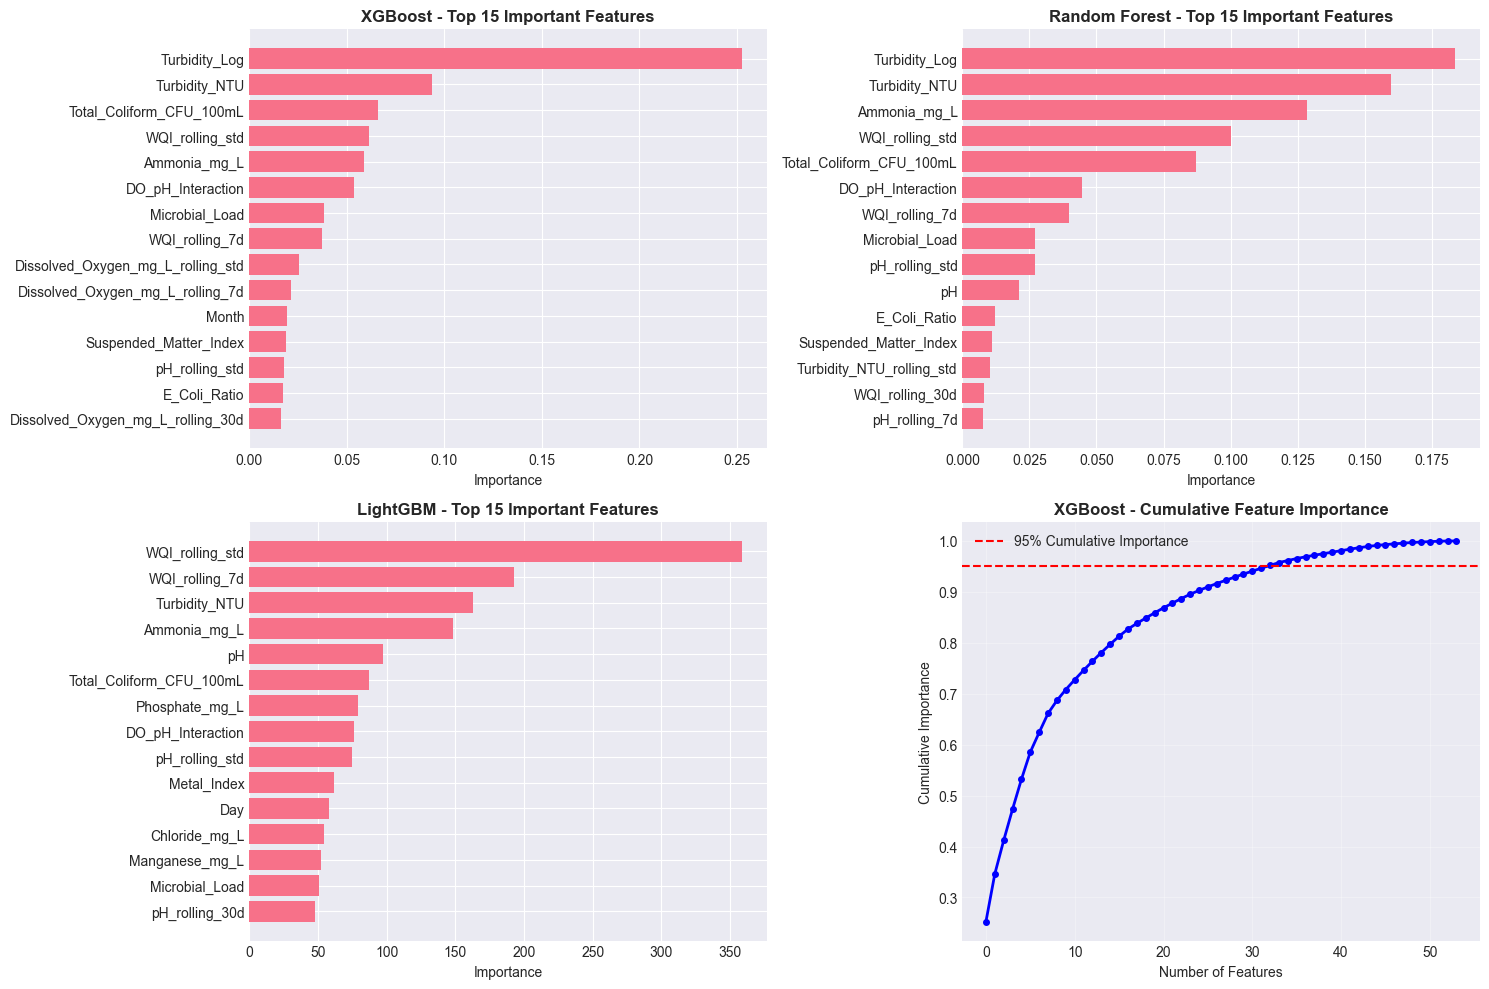

Feature importance visualizations generated


In [87]:
# Visualize feature importance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Use the exact feature set used during training
model_feature_cols = X_train.columns.tolist()

# XGBoost
feature_importance_xgb = pd.DataFrame({
    'Feature': model_feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_n = min(15, len(feature_importance_xgb))

ax1 = axes[0, 0]
ax1.barh(range(top_n), feature_importance_xgb['Importance'].head(top_n))
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(feature_importance_xgb['Feature'].head(top_n))
ax1.set_xlabel('Importance')
ax1.set_title('XGBoost - Top 15 Important Features', fontweight='bold')
ax1.invert_yaxis()

# Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': model_feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

ax2 = axes[0, 1]
ax2.barh(range(top_n), feature_importance_rf['Importance'].head(top_n))
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(feature_importance_rf['Feature'].head(top_n))
ax2.set_xlabel('Importance')
ax2.set_title('Random Forest - Top 15 Important Features', fontweight='bold')
ax2.invert_yaxis()

# LightGBM
feature_importance_lgb = pd.DataFrame({
    'Feature': model_feature_cols,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

ax3 = axes[1, 0]
ax3.barh(range(top_n), feature_importance_lgb['Importance'].head(top_n))
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(feature_importance_lgb['Feature'].head(top_n))
ax3.set_xlabel('Importance')
ax3.set_title('LightGBM - Top 15 Important Features', fontweight='bold')
ax3.invert_yaxis()

# Cumulative feature importance
ax4 = axes[1, 1]
cum_importance_xgb = np.cumsum(feature_importance_xgb['Importance'].values)
ax4.plot(cum_importance_xgb, 'b-o', linewidth=2, markersize=4)
ax4.axhline(y=0.95, color='r', linestyle='--', label='95% Cumulative Importance')
ax4.set_xlabel('Number of Features')
ax4.set_ylabel('Cumulative Importance')
ax4.set_title('XGBoost - Cumulative Feature Importance', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Feature importance visualizations generated")

## 7. Feature Importance Analysis

In [88]:
# Permutation Importance analysis for XGBoost model
print("="*80)
print("FEATURE IMPORTANCE - PERMUTATION METHOD")
print("="*80)

print("\nCalculating permutation feature importance...")

# Calculate permutation importance
perm_importance = permutation_importance(
    xgb_model, X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Use the actual feature names from X_test
actual_feature_cols = X_test.columns.tolist()

perm_importance_df = pd.DataFrame({
    'Feature': actual_feature_cols,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Permutation):")
print(perm_importance_df.head(10).to_string(index=False))
print("\nPermutation importance calculated")

FEATURE IMPORTANCE - PERMUTATION METHOD

Calculating permutation feature importance...

Top 10 Most Important Features (Permutation):
                 Feature  Importance      Std
            Ammonia_mg_L    0.286069 0.043580
           Turbidity_NTU    0.171716 0.050556
       DO_pH_Interaction    0.108957 0.023509
                      pH    0.061286 0.011078
Total_Coliform_CFU_100mL    0.060693 0.016643
          WQI_rolling_7d    0.027498 0.021269
         WQI_rolling_30d    0.011670 0.004072
          Phosphate_mg_L    0.008349 0.004213
            E_Coli_Ratio    0.007758 0.003379
           DayOfWeek_sin    0.006390 0.001580

Permutation importance calculated


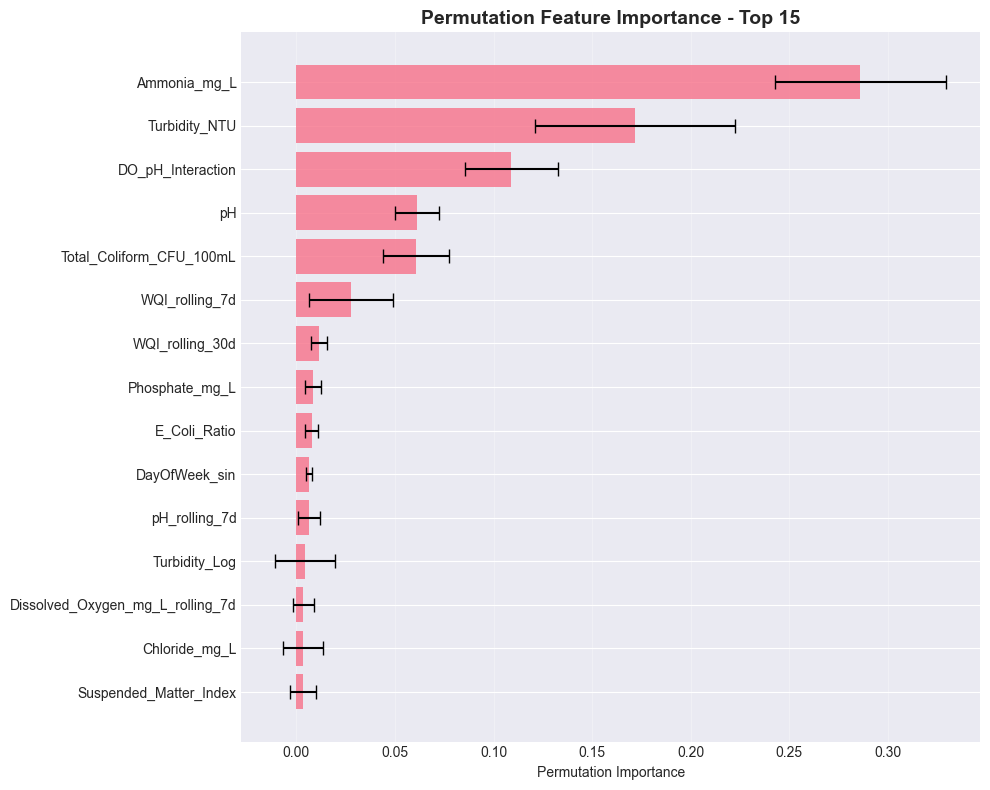

Permutation importance plot generated


In [89]:
# Permutation Importance plot
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = perm_importance_df.head(top_n)

ax.barh(range(len(top_features)), top_features['Importance'].values, 
        xerr=top_features['Std'].values, capsize=5, alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Permutation Importance')
ax.set_title('Permutation Feature Importance - Top 15', fontweight='bold', size=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Permutation importance plot generated")

## 8. Residual Analysis and Model Diagnostics

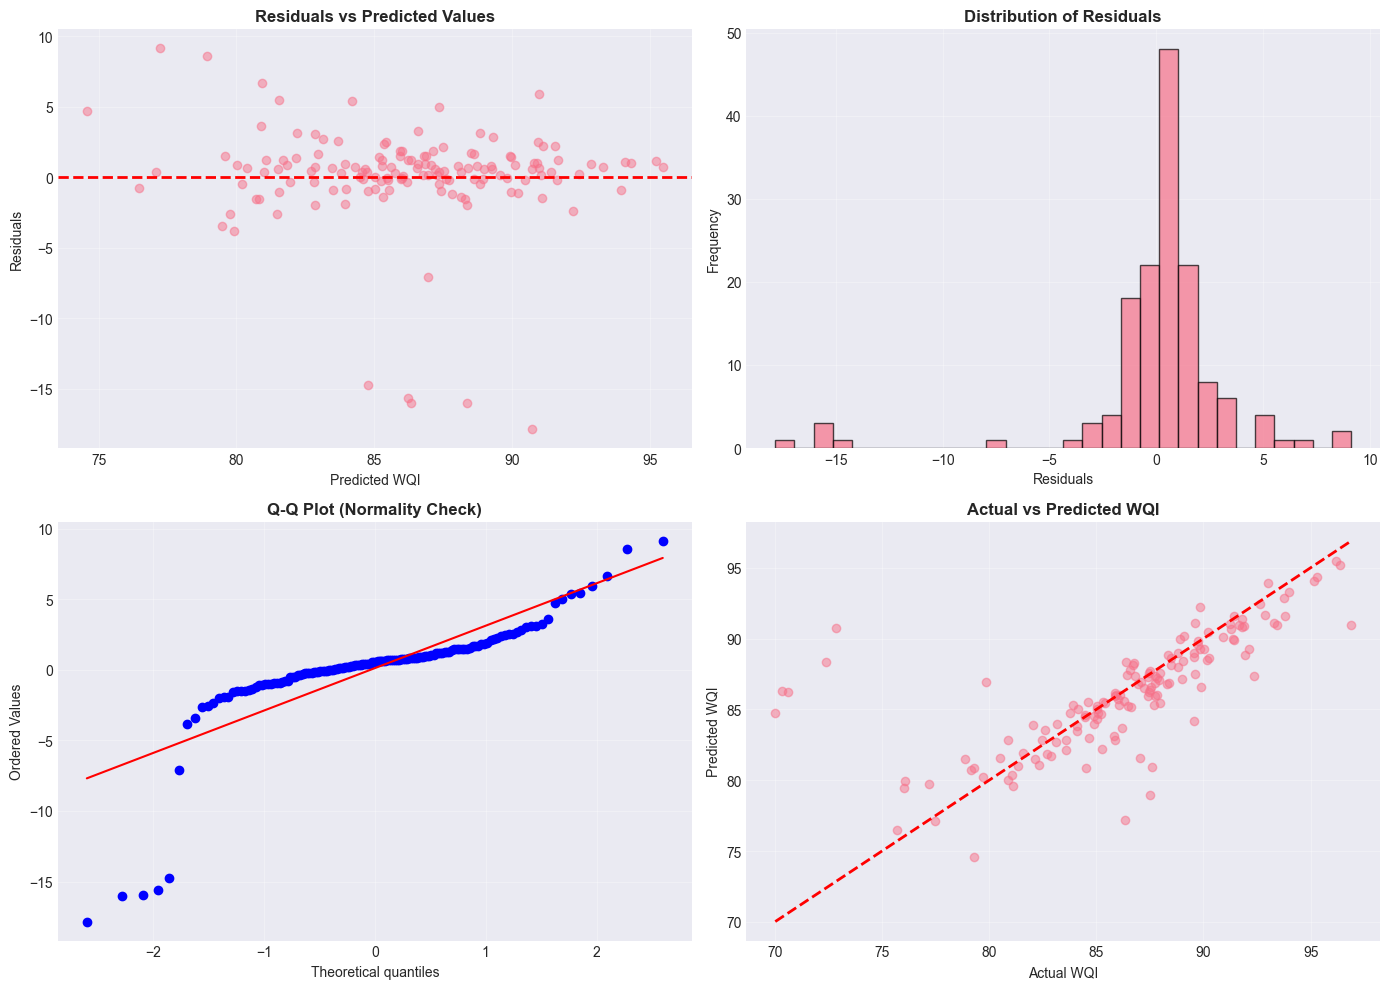

Residual analysis plots generated


In [90]:
# Calculate residuals for best model (XGBoost)
residuals = y_test - y_pred_xgb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_xgb, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted WQI')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Residuals distribution
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_xgb, alpha=0.5)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual WQI')
axes[1, 1].set_ylabel('Predicted WQI')
axes[1, 1].set_title('Actual vs Predicted WQI', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual analysis plots generated")

## 9. Save Models and Results

In [91]:
# Save best model and predictions
import pickle

print("\nSaving models and predictions...")

# Save best model (XGBoost)
with open('../outputs/best_model_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_XGBoost': y_pred_xgb,
    'Predicted_LightGBM': y_pred_lgb,
    'Predicted_RandomForest': y_pred_rf,
    'Residuals': residuals.values
})

predictions_df.to_csv('../outputs/model_predictions.csv', index=False)

# Save feature importance
feature_importance_xgb.to_csv('../outputs/feature_importance_xgboost.csv', index=False)
feature_importance_lgb.to_csv('../outputs/feature_importance_lightgbm.csv', index=False)
feature_importance_rf.to_csv('../outputs/feature_importance_randomforest.csv', index=False)

# Save model results
results_df.to_csv('../outputs/model_performance_comparison.csv', index=False)

print("Models and results saved successfully!")
print("\nFiles saved:")
print("  - best_model_xgboost.pkl")
print("  - scaler.pkl")
print("  - model_predictions.csv")
print("  - feature_importance_*.csv")
print("  - model_performance_comparison.csv")


Saving models and predictions...
Models and results saved successfully!

Files saved:
  - best_model_xgboost.pkl
  - scaler.pkl
  - model_predictions.csv
  - feature_importance_*.csv
  - model_performance_comparison.csv


## 10. Summary - Part 2 Complete

In [92]:
print("\n" + "="*80)
print("PART 2 - MODELING SUMMARY")
print("="*80)

print("\nFEATURE ENGINEERING:")
print("  - Domain-specific features created: 30+")
print("  - Interaction terms: DO-pH, Hardness-Conductivity")
print("  - Chemical indicators: Redox, Ion Balance")
print("  - Microbial indexes: Microbial Load, E. Coli Ratio")
print("  - Organic contamination: Organic Load, BOD/COD Ratio")
print("  - Temporal features: Rolling averages, standard deviations")

print("\nMODELS TRAINED:")
print("  1. Linear Regression")
print("  2. Random Forest")
print("  3. XGBoost (BEST)")
print("  4. LightGBM")

print("\nBEST MODEL PERFORMANCE (XGBoost):")
print(f"  R² Score: {r2_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  MAE: {mae_xgb:.4f}")
print(f"  Explains {r2_xgb*100:.2f}% variance in WQI")

print("\nTOP 5 IMPORTANT FEATURES:")
for i, row in feature_importance_xgb.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\nOn to Part 3: Dashboard & Deployment!")
print("="*80)


PART 2 - MODELING SUMMARY

FEATURE ENGINEERING:
  - Domain-specific features created: 30+
  - Interaction terms: DO-pH, Hardness-Conductivity
  - Chemical indicators: Redox, Ion Balance
  - Microbial indexes: Microbial Load, E. Coli Ratio
  - Organic contamination: Organic Load, BOD/COD Ratio
  - Temporal features: Rolling averages, standard deviations

MODELS TRAINED:
  1. Linear Regression
  2. Random Forest
  3. XGBoost (BEST)
  4. LightGBM

BEST MODEL PERFORMANCE (XGBoost):
  R² Score: 0.4919
  RMSE: 3.6477
  MAE: 1.9368
  Explains 49.19% variance in WQI

TOP 5 IMPORTANT FEATURES:
  39. Turbidity_Log: 0.2527
  3. Turbidity_NTU: 0.0937
  14. Total_Coliform_CFU_100mL: 0.0658
  52. WQI_rolling_std: 0.0614
  8. Ammonia_mg_L: 0.0587

On to Part 3: Dashboard & Deployment!
